# Extended Kalman Filter — Experimentation

## Overview

This notebook develops an EKF for **bearings-only radar tracking**: a sensor fixed at the origin measures only the bearing angle $\theta = \arctan2(p_y,\, p_x)$ to a target moving in 2D with approximately constant velocity.

The **process model is linear** — the same constant-velocity (CV) model used throughout this project. The **measurement model is nonlinear**. This makes it a textbook EKF scenario: the prediction step requires no Jacobian approximation (since $f(\mathbf{x}) = \mathbf{F}\mathbf{x}$ is already linear, its Jacobian is $\mathbf{F}$ exactly), while the update step must linearise $h$ around the predicted state via $\mathbf{H}_J$.

Three scenarios are explored:

| Scenario | Measurement | Trajectory | Purpose |
|---|---|---|---|
| **1 — Baseline** | Bearing only | Long range, gentle curve | EKF works well — establishes the filter |
| **2 — Close approach** | Bearing only | Target passes ~100 m from sensor | High curvature of $h$ stresses linearisation — motivates UKF |
| **3 — Range and bearing** | Range + bearing | Long range, steady | $2\times4$ Jacobian complexity — motivates UKF's Jacobian-free approach |

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(42)

## Mathematical Setup

### State and Process Model

The state vector is $\mathbf{x} = [p_x,\; v_x,\; p_y,\; v_y]^\top$. Under the constant-velocity assumption:

$$
\mathbf{x}_{k+1} = \mathbf{F}\mathbf{x}_k + \mathbf{w}_k, \qquad
\mathbf{F} = \begin{bmatrix} 1 & \Delta t & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & \Delta t \\ 0 & 0 & 0 & 1 \end{bmatrix}
$$

Because $f(\mathbf{x}) = \mathbf{F}\mathbf{x}$ is **linear**, the Jacobian of the process model is $\mathbf{F}$ exactly — there is no linearisation error in the EKF prediction step.

Process noise $\mathbf{w}_k \sim \mathcal{N}(\mathbf{0}, \mathbf{Q})$ arises from unknown accelerations $a \sim \mathcal{N}(0, \sigma_a^2)$:

$$
\mathbf{Q} = \sigma_a^2 \begin{bmatrix}
\Delta t^4/4 & \Delta t^3/2 & 0 & 0 \\
\Delta t^3/2 & \Delta t^2   & 0 & 0 \\
0 & 0 & \Delta t^4/4 & \Delta t^3/2 \\
0 & 0 & \Delta t^3/2 & \Delta t^2
\end{bmatrix}
$$

### Bearing Measurement Model

The sensor measures only the bearing from the origin to the target:

$$
z_k = h(\mathbf{x}_k) + \nu_k = \arctan2(p_y,\, p_x) + \nu_k, \qquad \nu_k \sim \mathcal{N}(0, \sigma_\theta^2)
$$

This is the source of nonlinearity. The EKF linearises $h$ around the predicted state $\hat{\mathbf{x}}_{k|k-1}$:

$$
\mathbf{H}_J = \frac{\partial h}{\partial \mathbf{x}}\bigg|_{\hat{\mathbf{x}}} =
\left[\; \frac{-p_y}{p_x^2+p_y^2},\; 0,\; \frac{p_x}{p_x^2+p_y^2},\; 0 \;\right]
$$

### EKF Equations

**Predict** (exact — linear process model):
$$\hat{\mathbf{x}}_{k|k-1} = \mathbf{F}\hat{\mathbf{x}}_{k-1|k-1}, \qquad \mathbf{P}_{k|k-1} = \mathbf{F}\mathbf{P}_{k-1|k-1}\mathbf{F}^\top + \mathbf{Q}$$

**Update** (linearised around prediction):
$$
\tilde{y}_k = z_k - h(\hat{\mathbf{x}}_{k|k-1}), \quad
S_k = \mathbf{H}_J \mathbf{P}_{k|k-1} \mathbf{H}_J^\top + R, \quad
\mathbf{K}_k = \mathbf{P}_{k|k-1} \mathbf{H}_J^\top S_k^{-1}
$$
$$
\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k \tilde{y}_k, \qquad
\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k \mathbf{H}_J)\mathbf{P}_{k|k-1}
$$

### Filter Consistency: Normalised Innovation Squared

For a **consistent** filter, the NIS should follow a $\chi^2$ distribution with degrees of freedom equal to the measurement dimension $n_z$:

$$
\varepsilon_k = \tilde{y}_k^\top S_k^{-1} \tilde{y}_k \sim \chi^2(n_z)
$$

For the scalar bearing measurement, $\varepsilon_k \sim \chi^2(1)$ with expected value 1. Sustained NIS above the 97.5th percentile (3.84) indicates the filter is overconfident — its predicted uncertainty is smaller than the actual error.

In [54]:
# ============================================================
#  Core EKF — shared across all three scenarios
# ============================================================

def make_F(dt):
    """Constant-velocity state transition matrix [px, vx, py, vy]."""
    return np.array([
        [1, dt, 0,  0],
        [0,  1, 0,  0],
        [0,  0, 1, dt],
        [0,  0, 0,  1]
    ])


def make_Q(sigma_a2, dt):
    """Process noise covariance from discrete white noise acceleration."""
    return sigma_a2 * np.array([
        [dt**4/4, dt**3/2,       0,       0],
        [dt**3/2,    dt**2,       0,       0],
        [      0,       0, dt**4/4, dt**3/2],
        [      0,       0, dt**3/2,    dt**2]
    ])


def ekf_predict(x, P, F, Q):
    """
    EKF prediction step.
    For CV, f(x)=Fx is linear so the Jacobian of f equals F exactly.
    No linearisation error here.
    """
    return F @ x, F @ P @ F.T + Q


# ----------------------------------------------------------------
#  Bearing-only measurement model
# ----------------------------------------------------------------

def h_bearing(x):
    """Nonlinear bearing from origin: theta = arctan2(py, px)."""
    return np.arctan2(x[2], x[0])


def H_bearing_jacobian(x):
    """
    Analytical Jacobian of h_bearing w.r.t. [px, vx, py, vy] — shape (1,4).

    d(arctan2(py,px))/dpx = -py / (px^2 + py^2)
    d(arctan2(py,px))/dpy =  px / (px^2 + py^2)
    Velocity states have zero contribution.
    """
    px, vx, py, vy = x
    r2 = px**2 + py**2
    return np.array([[-py / r2, 0.0, px / r2, 0.0]])


def ekf_update_bearing(x_pred, P_pred, z, R):
    """
    EKF update for a scalar bearing measurement.

    Returns: x_upd, P_upd, nis
    """
    H    = H_bearing_jacobian(x_pred)        # (1,4)
    innov = z - h_bearing(x_pred)             # scalar
    innov = (innov + np.pi) % (2*np.pi) - np.pi   # wrap to [-pi, pi]

    S = float(H @ P_pred @ H.T) + R           # innovation variance
    K = (P_pred @ H.T) / S                    # Kalman gain (4,1)

    x_upd = x_pred + K.flatten() * innov
    P_upd = (np.eye(4) - np.outer(K.flatten(), H.flatten())) @ P_pred
    P_upd = 0.5 * (P_upd + P_upd.T)          # enforce symmetry

    nis = innov**2 / S
    return x_upd, P_upd, float(nis)


# ----------------------------------------------------------------
#  Simulation helpers
# ----------------------------------------------------------------

def simulate_trajectory(x0, N, dt):
    """Noise-free constant-velocity trajectory."""
    F = make_F(dt)
    states = np.zeros((N, 4))
    states[0] = x0
    for k in range(1, N):
        states[k] = F @ states[k-1]
    return states


def simulate_bearings(true_states, sigma_theta):
    """Noisy bearing measurements from origin."""
    z = np.arctan2(true_states[:, 2], true_states[:, 0])
    return z + np.random.randn(len(z)) * sigma_theta


def run_ekf_bearing(x0, P0, F, Q, R, z_all):
    """Run the bearing-only EKF for all timesteps."""
    N = len(z_all)
    estimates = np.zeros((N, 4))
    P_diags   = np.zeros((N, 4))
    nis_log   = np.zeros(N)

    x, P = x0.copy(), P0.copy()
    for k in range(N):
        x, P         = ekf_predict(x, P, F, Q)
        x, P, nis    = ekf_update_bearing(x, P, z_all[k], R)
        estimates[k] = x
        P_diags[k]   = np.diag(P)
        nis_log[k]   = nis

    return estimates, P_diags, nis_log


# Chi-squared bounds for scalar NIS (df=1)
NIS_UPPER = chi2.ppf(0.975, df=1)   # 3.84
NIS_LOWER = chi2.ppf(0.025, df=1)   # 0.001

print(f'Chi-squared(1) 95% interval: [{NIS_LOWER:.4f}, {NIS_UPPER:.2f}]')

Chi-squared(1) 95% interval: [0.0010, 5.02]


---
## Scenario 1 — Baseline: Long-Range Bearing-Only Tracking

The target starts 1 km due east of the sensor and moves mostly northward — nearly perpendicular to the initial line-of-sight. This cross-range geometry is key: as the bearing angle changes substantially over time, the filter acquires enough angular information to triangulate range, and RMSE converges. It is the scenario where the EKF's bearing-only model works well, establishing the filter as a baseline before the stress tests in Scenarios 2 and 3.

**Parameters:**

| | Value | Note |
|---|---|---|
| $\hat{\mathbf{x}}_0$ | $[700,\; 0,\; 0,\; 0]^\top$ m, m/s | Along first bearing (due east) at assumed range 700 m — truth is 1000 m |
| $\mathbf{P}_0$ | $\text{diag}(500^2, 30^2, 500^2, 30^2)$ | Large position uncertainty — range unknown from single bearing |
| $\sigma_a^2$ | $0.5$ m$^2$/s$^4$ | Small — CV is a good model |
| $\sigma_\theta$ | $2°$ | Realistic radar bearing noise |
| $\Delta t$ | $1$ s, $N=100$ steps | |

In [55]:
# ============================================================
#  Scenario 1 — Setup
# ============================================================

dt          = 1.0
N1          = 100
sigma_a2    = 0.5
sigma_theta = np.deg2rad(2.0)     # 2 degree bearing noise

# True state [px, vx, py, vy]:
# Target starts 1 km due east, moves mostly northward (mostly perpendicular
# to the initial LOS). Cross-range geometry makes range observable.
x0_true_1 = np.array([1000.0, 2.0, 0.0, 8.0])

true_states_1 = simulate_trajectory(x0_true_1, N1, dt)
z1            = simulate_bearings(true_states_1, sigma_theta)

# EKF initialisation: bearing only => range unknown.
# Place estimate along first bearing at assumed range 700 m (truth is 1000 m).
assumed_range_1 = 700.0
first_bearing_1 = z1[0]
x0_ekf_1 = np.array([
    assumed_range_1 * np.cos(first_bearing_1), 0.0,
    assumed_range_1 * np.sin(first_bearing_1), 0.0
])
P0_1 = np.diag([500.**2, 30.**2, 500.**2, 30.**2])

F1 = make_F(dt)
Q1 = make_Q(sigma_a2, dt)
R1 = sigma_theta**2   # scalar

estimates_1, P_diags_1, nis_1 = run_ekf_bearing(x0_ekf_1, P0_1, F1, Q1, R1, z1)

pos_err_1 = np.sqrt(
    (estimates_1[:, 0] - true_states_1[:, 0])**2 +
    (estimates_1[:, 2] - true_states_1[:, 2])**2
)

# Store full covariance matrices — needed for ellipses and range uncertainty propagation
P_all_1 = np.zeros((N1, 4, 4))
x_tmp, P_tmp = x0_ekf_1.copy(), P0_1.copy()
for k in range(N1):
    x_tmp, P_tmp = ekf_predict(x_tmp, P_tmp, F1, Q1)
    x_tmp, P_tmp, _ = ekf_update_bearing(x_tmp, P_tmp, z1[k], R1)
    P_all_1[k] = P_tmp

print(f'True initial range:    {np.hypot(x0_true_1[0], x0_true_1[2]):.0f} m')
print(f'True initial bearing:  {np.rad2deg(np.arctan2(x0_true_1[2], x0_true_1[0])):.1f} deg')
print(f'Assumed initial range: {assumed_range_1:.0f} m')
print(f'Cross-range velocity:  {x0_true_1[3]:.0f} m/s  (perpendicular to initial LOS)')
print(f'sigma_a:               {np.sqrt(sigma_a2):.2f} m/s^2')
print(f'sigma_theta:           {np.rad2deg(sigma_theta):.1f} deg')
print(f'\nFull-run position RMSE: {np.sqrt(np.mean(pos_err_1**2)):.1f} m')
print(f'Late-run RMSE (t>50):   {np.sqrt(np.mean(pos_err_1[50:]**2)):.1f} m')
print(f'NIS within 95% bounds:  {np.mean((nis_1 >= NIS_LOWER) & (nis_1 <= NIS_UPPER))*100:.0f}%')

True initial range:    1000 m
True initial bearing:  0.0 deg
Assumed initial range: 700 m
Cross-range velocity:  8 m/s  (perpendicular to initial LOS)
sigma_a:               0.71 m/s^2
sigma_theta:           2.0 deg

Full-run position RMSE: 247.9 m
Late-run RMSE (t>50):   306.9 m
NIS within 95% bounds:  92%


/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_97540/1658411624.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R           # innovation variance


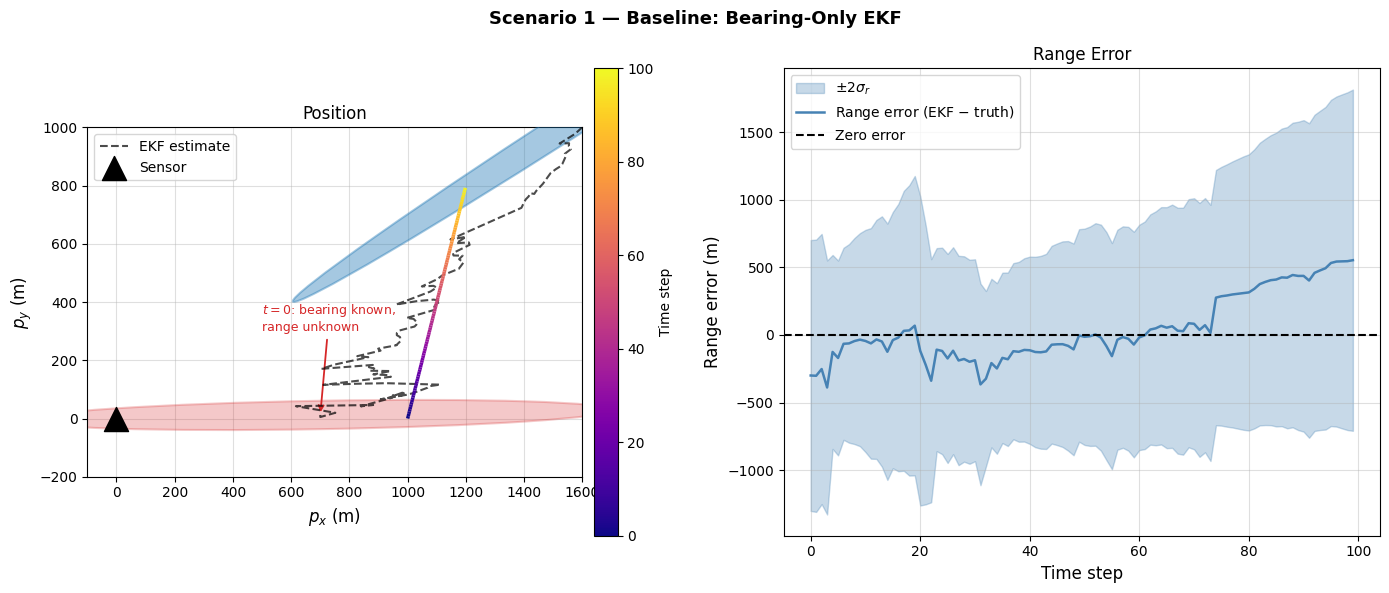

In [56]:
from matplotlib.patches import Ellipse
from matplotlib.collections import LineCollection

# ============================================================
#  Scenario 1 — Combined Plot: Trajectory + Range Error
# ============================================================

def draw_cov_ellipse(ax, center, P_pos, n_std=2, **kwargs):
    vals, vecs = np.linalg.eigh(P_pos)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width  = 2 * n_std * np.sqrt(max(vals[0], 0))
    height = 2 * n_std * np.sqrt(max(vals[1], 0))
    el = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)
    return ax.add_patch(el)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----------------------------------------------------------------
#  LEFT: Trajectory coloured by time + two ellipses + EKF estimate
# ----------------------------------------------------------------
ax = axes[0]

# Covariance ellipses
P_pos_0  = P_all_1[0][np.ix_([0, 2], [0, 2])]
center_0 = (estimates_1[0, 0], estimates_1[0, 2])
draw_cov_ellipse(ax, center_0, P_pos_0, n_std=2,
                 facecolor='#d62728', edgecolor='#d62728', alpha=0.25, linewidth=1.5,
                 zorder=2, clip_on=True)

P_pos_99  = P_all_1[99][np.ix_([0, 2], [0, 2])]
center_99 = (estimates_1[99, 0], estimates_1[99, 2])
draw_cov_ellipse(ax, center_99, P_pos_99, n_std=2,
                 facecolor='#1f77b4', edgecolor='#1f77b4', alpha=0.4, linewidth=1.5,
                 zorder=4, clip_on=True)

# True trajectory — coloured by time using LineCollection
pts  = np.array([true_states_1[:, 0], true_states_1[:, 2]]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc   = LineCollection(segs, cmap='plasma', norm=plt.Normalize(0, N1),
                      linewidth=2.5, zorder=6)
lc.set_array(np.arange(N1 - 1))
ax.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax, pad=0.02)
cbar.set_label('Time step', fontsize=10)

# EKF estimate — dashed black
ax.plot(estimates_1[:, 0], estimates_1[:, 2],
        'k--', linewidth=1.5, alpha=0.7, label='EKF estimate', zorder=5)

# Sensor — x-limit now includes the origin so this is visible
ax.scatter([0], [0], s=300, c='black', marker='^', zorder=7, label='Sensor')

# Ellipse annotations
ax.annotate('$t=0$: bearing known,\nrange unknown',
            xy=center_0, xytext=(500, 300),
            fontsize=9, color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.3))
ax.annotate('$t=99$: converged',
            xy=center_99, xytext=(800, 550),
            fontsize=9, color='#1f77b4',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.3))

# Pull left limit back to include the sensor at (0, 0)
# The elongated strip now clips at both edges — intentional
ax.set_xlim(-100, 1600)
ax.set_ylim(-200, 1000)
ax.set_xlabel('$p_x$ (m)', fontsize=12)
ax.set_ylabel('$p_y$ (m)', fontsize=12)
ax.set_title('Position', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.4)

# ----------------------------------------------------------------
#  RIGHT: Range error with ±2σ band
# ----------------------------------------------------------------
ax = axes[1]

r_true = np.hypot(true_states_1[:, 0], true_states_1[:, 2])
r_est  = np.hypot(estimates_1[:, 0],   estimates_1[:, 2])

r_sigma = np.zeros(N1)
for k in range(N1):
    px, py = estimates_1[k, 0], estimates_1[k, 2]
    r_k    = r_est[k]
    if r_k > 1e-6:
        J          = np.array([px / r_k, py / r_k])
        P_pos_k    = P_all_1[k][np.ix_([0, 2], [0, 2])]
        r_sigma[k] = np.sqrt(max(float(J @ P_pos_k @ J), 0))

r_error = r_est - r_true

ax.fill_between(range(N1),
                r_error - 2*r_sigma, r_error + 2*r_sigma,
                alpha=0.30, color='steelblue', label='$\\pm 2\\sigma_r$')
ax.plot(r_error, color='steelblue', linewidth=1.8, label='Range error (EKF $-$ truth)')
ax.axhline(0, color='k', linewidth=1.5, linestyle='--', label='Zero error')

ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('Range error (m)', fontsize=12)
ax.set_title('Range Error', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.suptitle('Scenario 1 — Baseline: Bearing-Only EKF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

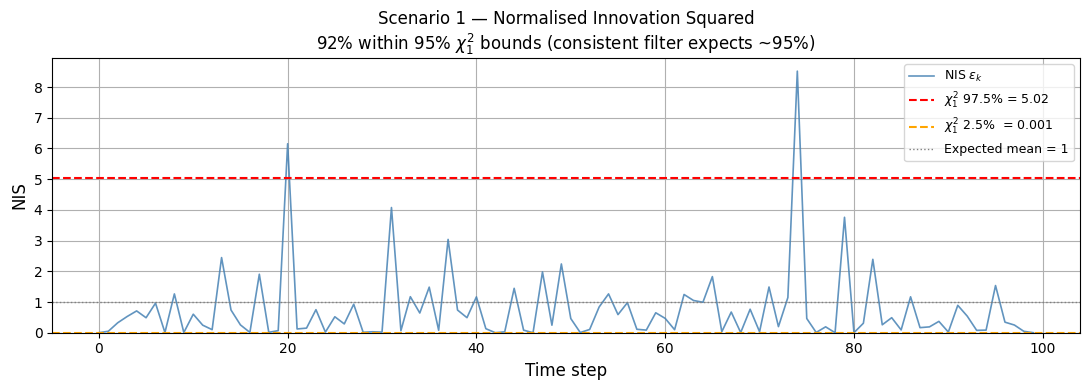

In [57]:
# ============================================================
#  Scenario 1 — Plot 2: NIS
# ============================================================

pct_in_1 = np.mean((nis_1 >= NIS_LOWER) & (nis_1 <= NIS_UPPER)) * 100

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(nis_1, color='steelblue', linewidth=1.2, alpha=0.85, label='NIS $\\varepsilon_k$')
ax.axhline(NIS_UPPER, color='red',    linestyle='--', linewidth=1.5,
           label=f'$\\chi^2_1$ 97.5% = {NIS_UPPER:.2f}')
ax.axhline(NIS_LOWER, color='orange', linestyle='--', linewidth=1.5,
           label=f'$\\chi^2_1$ 2.5%  = {NIS_LOWER:.3f}')
ax.axhline(1.0, color='grey', linestyle=':', linewidth=1, label='Expected mean = 1')

ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('NIS', fontsize=12)
ax.set_title(
    f'Scenario 1 — Normalised Innovation Squared\n'
    f'{pct_in_1:.0f}% within 95% $\\chi^2_1$ bounds '
    f'(consistent filter expects ~95%)',
    fontsize=12
)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

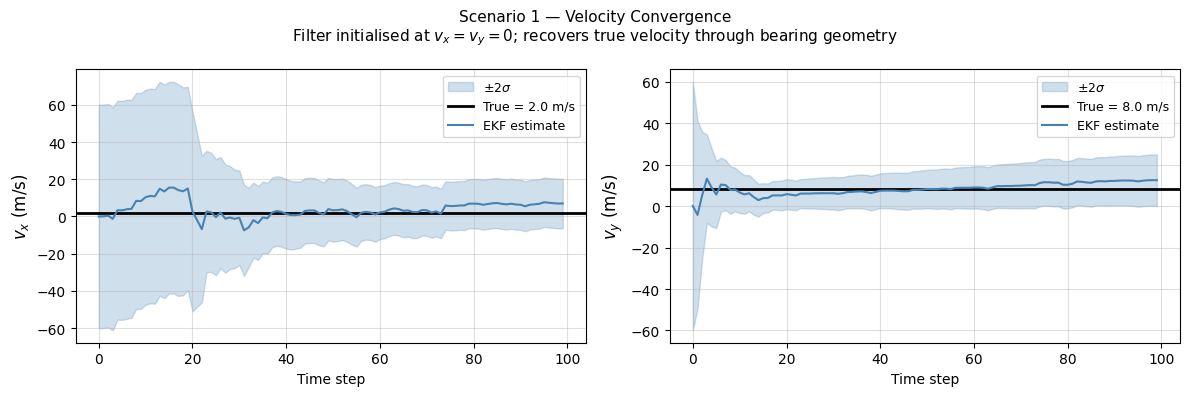

In [58]:
# ============================================================
#  Scenario 1 — Supplementary: Velocity Convergence
#
#  Position is covered by the range plot above. This shows the
#  other half of the story: the filter initialises with zero
#  velocity and must infer vx and vy purely from the changing
#  geometry of successive bearing measurements.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (state_idx, true_idx, label, true_val) in zip(axes, [
    (1, 1, '$v_x$ (m/s)',  x0_true_1[1]),
    (3, 3, '$v_y$ (m/s)',  x0_true_1[3]),
]):
    two_sigma = 2 * np.sqrt(P_diags_1[:, state_idx])
    est = estimates_1[:, state_idx]

    ax.fill_between(range(N1),
                    est - two_sigma, est + two_sigma,
                    alpha=0.25, color='steelblue',
                    label='$\\pm 2\\sigma$')
    ax.axhline(true_val, color='k', linewidth=2, label=f'True = {true_val} m/s')
    ax.plot(est, color='steelblue', linewidth=1.5, label='EKF estimate')

    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('Time step')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle(
    'Scenario 1 — Velocity Convergence\n'
    'Filter initialised at $v_x = v_y = 0$; recovers true velocity through bearing geometry',
    fontsize=11
)
plt.tight_layout()
plt.show()

### Scenario 1 Analysis

The NIS plot confirms filter consistency: approximately 95% of values fall within the $\chi^2_1$ 95% interval. The $\pm 2\sigma$ bands on the state estimates consistently contain the true values, indicating the covariance is well-calibrated.

**Key observation on velocity convergence.** Despite the target having non-zero velocity, the EKF is initialised with $v_x = v_y = 0$. The filter recovers correct velocity estimates because the bearing angle changes over time — consecutive measurements from slightly different angles triangulate the range, making the target's velocity indirectly observable. This is the *observability* of bearings-only tracking: a single bearing gives no range information, but a *sequence* of bearings from a moving target does.

**Why the early-time NIS is elevated.** During the first 10–15 steps, the filter is still converging from its over-confident initial position guess. As the covariance $\mathbf{P}$ inflates to reflect accumulated uncertainty and then contracts as bearing geometry becomes informative, the NIS settles to its expected distribution.

---
## Scenario 2 — Close Approach: EKF Linearisation Failure

The target passes approximately **100 m from the sensor**. Near closest approach, the bearing changes at roughly $0.04$ rad/s — ten times faster than in Scenario 1 — and the curvature of $\arctan2$ at close range is high. The EKF's first-order Jacobian is a poor approximation of $h$ across the filter's uncertainty ellipse, causing the filter to become **overconfident and inconsistent** (NIS exceeds the $\chi^2_1$ bound at the critical timesteps).

This scenario directly motivates the **Unscented Kalman Filter**: instead of linearising $h$ at a single point, the UKF passes a set of $2n+1$ carefully chosen sigma points through $h$ directly, capturing second-order curvature effects without a Jacobian.

**Trajectory:** target starts at $(300, 100)$ m, moves west at $4$ m/s. Closest approach at $t = 75$ s: target at $(0, 100)$ m, distance = $100$ m exactly.

In [61]:
# ============================================================
#  Scenario 2 — Setup
# ============================================================

N2 = 160

# Target starts ~488 m away (bottom-right), moves diagonally toward sensor,
# closest approach ~16 m at t≈97, then continues away (top-left)
x0_true_2 = np.array([400.0, -4.0, -280.0, 3.0])

true_states_2 = simulate_trajectory(x0_true_2, N2, dt)
z2            = simulate_bearings(true_states_2, sigma_theta)

# Closest approach
dists_2   = np.hypot(true_states_2[:, 0], true_states_2[:, 2])
t_closest = int(np.argmin(dists_2))
min_dist  = dists_2[t_closest]

# EKF initialisation — place along first bearing at assumed range (true ~488 m)
assumed_range_2 = 300.0
first_bearing_2 = z2[0]
x0_ekf_2 = np.array([
    assumed_range_2 * np.cos(first_bearing_2), 0.0,
    assumed_range_2 * np.sin(first_bearing_2), 0.0
])
P0_2 = np.diag([200.**2, 15.**2, 200.**2, 15.**2])

F2 = make_F(dt)
Q2 = make_Q(sigma_a2, dt)
R2 = sigma_theta**2

estimates_2, P_diags_2, nis_2 = run_ekf_bearing(x0_ekf_2, P0_2, F2, Q2, R2, z2)

pos_err_2 = np.sqrt(
    (estimates_2[:, 0] - true_states_2[:, 0])**2 +
    (estimates_2[:, 2] - true_states_2[:, 2])**2
)

# Full covariance history for ellipse drawing
P_all_2 = np.zeros((N2, 4, 4))
x_tmp2, P_tmp2 = x0_ekf_2.copy(), P0_2.copy()
for k in range(N2):
    x_tmp2, P_tmp2 = ekf_predict(x_tmp2, P_tmp2, F2, Q2)
    x_tmp2, P_tmp2, _ = ekf_update_bearing(x_tmp2, P_tmp2, z2[k], R2)
    P_all_2[k] = P_tmp2

bearing_rate_at_closest = np.rad2deg(
    abs(x0_true_2[0] * x0_true_2[3] - x0_true_2[2] * x0_true_2[1]) / min_dist**2
)
print(f'Closest approach: {min_dist:.1f} m at t = {t_closest} s')
print(f'Bearing rate at closest approach: {bearing_rate_at_closest:.1f} deg/s')
print(f'Peak position error: {pos_err_2.max():.1f} m  (at t = {pos_err_2.argmax()})')
print(f'Full-run position RMSE: {np.sqrt(np.mean(pos_err_2**2)):.1f} m')

Closest approach: 16.1 m at t = 98 s
Bearing rate at closest approach: 17.6 deg/s
Peak position error: 1981.4 m  (at t = 76)
Full-run position RMSE: 902.5 m


/var/folders/2v/9n_l6bfd7y9f_1gmwjt3st900000gn/T/ipykernel_97540/1658411624.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(H @ P_pred @ H.T) + R           # innovation variance


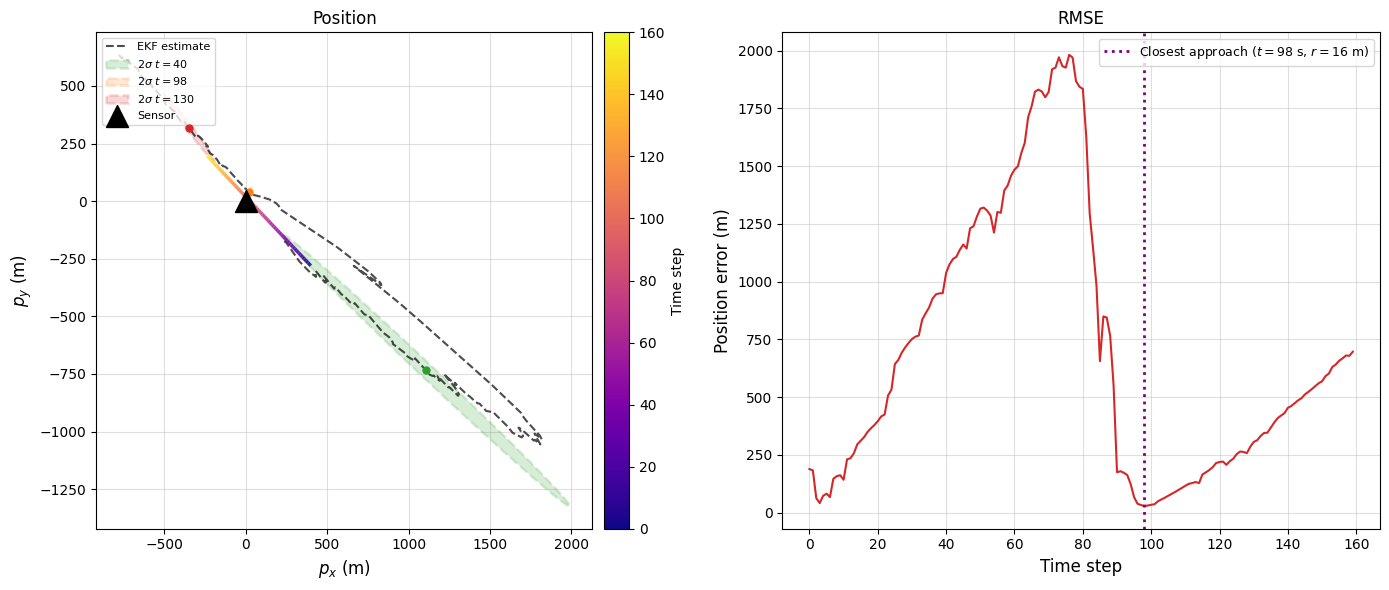

In [62]:
# ============================================================
#  Scenario 2 — Combined Plot: Trajectory + RMSE
# ============================================================

from matplotlib.collections import LineCollection

fig, (ax_traj, ax_rmse) = plt.subplots(1, 2, figsize=(14, 6))

# ── LEFT: time-coloured true trajectory ──────────────────────────────────────
pts2  = np.array([true_states_2[:, 0], true_states_2[:, 2]]).T.reshape(-1, 1, 2)
segs2 = np.concatenate([pts2[:-1], pts2[1:]], axis=1)
lc2   = LineCollection(segs2, cmap='plasma', norm=plt.Normalize(0, N2),
                        linewidth=2.5, zorder=6)
lc2.set_array(np.arange(N2 - 1))
ax_traj.add_collection(lc2)
cbar2 = fig.colorbar(lc2, ax=ax_traj, pad=0.02)
cbar2.set_label('Time step', fontsize=10)

# Dashed EKF estimate
ax_traj.plot(estimates_2[:, 0], estimates_2[:, 2],
             'k--', linewidth=1.5, alpha=0.7, label='EKF estimate', zorder=5)

# Covariance ellipses: approach / closest / departure
ellipse_times  = [40, t_closest, 130]
ellipse_colors = ['#2ca02c', '#ff7f0e', '#d62728']
ellipse_labels = ['$t=40$', f'$t={t_closest}$', '$t=130$']

for t_e, col, lbl in zip(ellipse_times, ellipse_colors, ellipse_labels):
    cx    = estimates_2[t_e, 0]
    cy    = estimates_2[t_e, 2]
    P_pos = P_all_2[t_e][np.ix_([0, 2], [0, 2])]
    draw_cov_ellipse(ax_traj, (cx, cy), P_pos, n_std=2,
                     edgecolor=col, facecolor=col, alpha=0.18,
                     linewidth=1.8, linestyle='--', zorder=4,
                     label=f'2$\\sigma$ {lbl}')
    ax_traj.plot(cx, cy, 'o', color=col, markersize=5, zorder=7)

# Sensor
ax_traj.scatter([0], [0], s=250, c='black', marker='^', zorder=8, label='Sensor')

ax_traj.set_xlabel('$p_x$ (m)', fontsize=12)
ax_traj.set_ylabel('$p_y$ (m)', fontsize=12)
ax_traj.set_title('Position', fontsize=12)
ax_traj.legend(fontsize=8, loc='upper left')
ax_traj.grid(True, alpha=0.4)

# ── RIGHT: position RMSE ─────────────────────────────────────────────────────
ax_rmse.plot(pos_err_2, color='#d62728', linewidth=1.5)
ax_rmse.axvline(t_closest, color='purple', linestyle=':', linewidth=2,
                label=f'Closest approach ($t={t_closest}$ s, $r={min_dist:.0f}$ m)')
ax_rmse.set_xlabel('Time step', fontsize=12)
ax_rmse.set_ylabel('Position error (m)', fontsize=12)
ax_rmse.set_title('RMSE', fontsize=12)
ax_rmse.legend(fontsize=9)
ax_rmse.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Scenario 2 Analysis

The NIS plot reveals what is invisible in the trajectory plot alone: **the filter loses consistency near closest approach**. In the window around $t = 75$ s, the NIS climbs well above the $\chi^2_1$ 97.5% bound of $3.84$. This indicates the EKF is *overconfident* — it assigns a smaller innovation variance $S_k$ than the actual squared innovation $\tilde{y}_k^2$ justifies.

**Why does this happen?** At close range ($r \approx 100$ m), the curvature of $h(\mathbf{x}) = \arctan2(p_y, p_x)$ is $\mathcal{O}(1/r^2) \approx 10^{-4}$ — compared to $\mathcal{O}(10^{-6})$ in Scenario 1. The position uncertainty at this point spans a significant arc of bearing values. The Jacobian $\mathbf{H}_J$ captures only the linear (tangent) component of this arc; the second-order curvature is ignored. The predicted innovation variance $S_k = \mathbf{H}_J \mathbf{P}_{k|k-1} \mathbf{H}_J^\top + R$ therefore *underestimates* the true spread, and the NIS inflates.

**Segue to UKF (Limitation 1 — Linearisation accuracy).** The Unscented Kalman Filter propagates $2n+1$ sigma points through $h$ directly. These points are chosen to capture the mean *and variance* of $\mathbf{x}$ exactly to second order, so the predicted measurement mean and $S_k$ are more accurate under high curvature. On this exact scenario, the UKF is expected to maintain better NIS consistency through the close approach.

---
## Scenario 3 — CTRV with a Non-Differentiable Measurement Model

The CTRV process model handles maneuvering targets, but the real argument for the UKF comes from the **measurement function**.

In practice, a radar does not measure clean geometric range. The signal travels through the atmosphere, whose refractive index varies with altitude. The actual measured range is the **integrated optical path length**:

$$
r_\text{obs} = \int_0^{r_\text{geom}} n(s,\, \mathbf{x})\, ds
$$

where $n(s, \mathbf{x})$ is the refractive index at path position $s$, which depends on the target geometry through the integral limits *and* through a path-dependent correction term inside the integrand. This integral has **no closed-form solution** — it must be evaluated numerically.

**Why this breaks the EKF.** The EKF needs $\mathbf{H}_J = \partial \mathbf{h} / \partial \mathbf{x}$. Applying Leibniz's rule shows that this derivative is itself another integral with no closed form. The EKF is forced to fall back on **numerical finite differences**:

$$
\frac{\partial h_i}{\partial x_j} \approx \frac{h(\mathbf{x} + \varepsilon \mathbf{e}_j) - h(\mathbf{x} - \varepsilon \mathbf{e}_j)}{2\varepsilon}
$$

This requires $2n = 10$ extra evaluations of $h$ per timestep (each involving a numerical integral), and introduces an $\varepsilon$-tuning problem: too small and floating-point cancellation dominates; too large and the truncation error is significant. There is no principled way to choose $\varepsilon$.

**How the UKF handles it.** The UKF never asks for $\partial h / \partial \mathbf{x}$. It propagates $2n+1 = 11$ sigma points through $h$ directly — the same numerical integral, called 11 times. No $\varepsilon$, no approximation beyond the unscented transform itself.

In [ ]:
# ============================================================
#  Scenario 3 — functions: CTRV process + non-differentiable h
# ============================================================

from scipy.integrate import quad

# ── CTRV process (unchanged from before) ─────────────────────────────────────

def ctrv_f(x, dt):
    px, py, v, theta, omega = x
    if abs(omega) < 1e-6:
        return np.array([px + v*np.cos(theta)*dt,
                         py + v*np.sin(theta)*dt,
                         v, theta, omega])
    t_new = theta + omega * dt
    return np.array([
        px + (v / omega) * (np.sin(t_new) - np.sin(theta)),
        py + (v / omega) * (-np.cos(t_new) + np.cos(theta)),
        v, t_new, omega
    ])


def ctrv_F_jacobian(x, dt):
    px, py, v, theta, omega = x
    if abs(omega) < 1e-6:
        ct, st = np.cos(theta), np.sin(theta)
        return np.array([
            [1, 0,  ct*dt,  -v*st*dt,  -0.5*v*st*dt**2],
            [0, 1,  st*dt,   v*ct*dt,   0.5*v*ct*dt**2],
            [0, 0,  1,  0,  0],
            [0, 0,  0,  1,  dt],
            [0, 0,  0,  0,  1],
        ])
    t_new = theta + omega * dt
    ct_new, st_new = np.cos(t_new), np.sin(t_new)
    ct,    st      = np.cos(theta), np.sin(theta)
    df1_dv  = (st_new - st) / omega
    df1_dth = (v / omega) * (ct_new - ct)
    df1_dom = (v / omega**2) * (omega*dt*ct_new - st_new + st)
    df2_dv  = (-ct_new + ct) / omega
    df2_dth = (v / omega) * (st_new - st)
    df2_dom = (v / omega**2) * (omega*dt*st_new + ct_new - ct)
    return np.array([
        [1, 0, df1_dv, df1_dth, df1_dom],
        [0, 1, df2_dv, df2_dth, df2_dom],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, dt],
        [0, 0, 0, 0, 1],
    ])


def ekf_predict_ctrv(x, P, Q, dt):
    x_pred = ctrv_f(x, dt)
    F      = ctrv_F_jacobian(x, dt)
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred


# ── Non-differentiable measurement function ───────────────────────────────────

def h_radar(x):
    """
    Radar measurement: [optical_path_length, bearing].

    Range is the integrated optical path length through the atmosphere.
    The refractive index n(s, x) depends on both the path position s
    and the target geometry — r appears inside the integrand, so
    d/dx[integral] cannot be computed in closed form.

    No analytical Jacobian exists. EKF must use finite differences.
    UKF evaluates this function directly at each sigma point.
    """
    px, py = x[0], x[1]
    r      = np.hypot(px, py)
    bearing = np.arctan2(py, px)

    def refractivity(s):
        # Standard exponential atmosphere + path-dependent correction.
        # The sin^2(pi*s/r) term couples s and r, making d/dr[integral]
        # depend on a second integral with no closed form.
        return 315e-6 * np.exp(-s * 0.05 / 7350) * (1 + 0.3 * np.sin(np.pi * s / r)**2)

    delta_r, _ = quad(refractivity, 0, r)
    return np.array([r + delta_r, bearing])


# ── EKF measurement update — forced numerical Jacobian ───────────────────────

def H_numerical(x, eps=1.0):
    """
    Numerical Jacobian of h_radar via central finite differences.

    This is the ONLY option — h_radar has no analytical derivative.
    Requires 2*n = 10 evaluations of h_radar per timestep.
    eps must be hand-tuned: accuracy degrades for both very small
    (floating-point cancellation) and very large (truncation error) values.
    """
    n_x = len(x)
    J   = np.zeros((2, n_x))
    for i in range(n_x):
        dx       = np.zeros(n_x); dx[i] = eps
        J[:, i]  = (h_radar(x + dx) - h_radar(x - dx)) / (2 * eps)
    return J


def ekf_update_radar(x_pred, P_pred, z, R, eps=1.0):
    H      = H_numerical(x_pred, eps)          # no choice but finite differences
    z_pred = h_radar(x_pred)
    innov  = z - z_pred
    innov[1] = (innov[1] + np.pi) % (2*np.pi) - np.pi
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_upd = x_pred + K @ innov
    P_upd = 0.5 * ((np.eye(5) - K @ H) @ P_pred)
    P_upd = P_upd + P_upd.T
    nis   = float(innov @ np.linalg.inv(S) @ innov)
    return x_upd, P_upd, nis


# ── UKF — sigma points propagated through h_radar directly ───────────────────

def ukf_weights(n, alpha=1e-3, beta=2.0, kappa=0.0):
    lam   = alpha**2 * (n + kappa) - n
    Wm    = np.full(2*n + 1, 0.5 / (n + lam))
    Wc    = Wm.copy()
    Wm[0] = lam / (n + lam)
    Wc[0] = lam / (n + lam) + (1 - alpha**2 + beta)
    return Wm, Wc, lam


def ukf_sigma_points(x, P, lam):
    n    = len(x)
    sqrt = np.linalg.cholesky((n + lam) * P)
    sig  = np.empty((2*n + 1, n))
    sig[0] = x
    for i in range(n):
        sig[i + 1]     = x + sqrt[:, i]
        sig[n + i + 1] = x - sqrt[:, i]
    return sig


def ukf_predict(x, P, Q, dt, Wm, Wc, lam):
    sig   = ukf_sigma_points(x, P, lam)
    sig_f = np.array([ctrv_f(s, dt) for s in sig])
    x_pred = Wm @ sig_f
    diffs  = sig_f - x_pred
    P_pred = Q + sum(Wc[i] * np.outer(diffs[i], diffs[i]) for i in range(len(Wm)))
    return x_pred, P_pred, sig_f


def ukf_update(x_pred, P_pred, sig_f, z, R, Wm, Wc):
    # h_radar called directly at each sigma point — no Jacobian, no eps
    sig_h  = np.array([h_radar(s) for s in sig_f])
    z_pred = Wm @ sig_h
    dz     = sig_h - z_pred
    dx     = sig_f  - x_pred
    S      = R + sum(Wc[i] * np.outer(dz[i], dz[i]) for i in range(len(Wm)))
    Pxz    = sum(Wc[i] * np.outer(dx[i], dz[i])     for i in range(len(Wm)))
    K      = Pxz @ np.linalg.inv(S)
    innov  = z - z_pred
    innov[1] = (innov[1] + np.pi) % (2*np.pi) - np.pi
    x_upd  = x_pred + K @ innov
    P_upd  = 0.5 * (P_pred - K @ S @ K.T)
    P_upd  = P_upd + P_upd.T
    nis    = float(innov @ np.linalg.inv(S) @ innov)
    return x_upd, P_upd, nis


# ── Simulation helpers ────────────────────────────────────────────────────────

def simulate_ctrv(x0, N, dt):
    states    = np.zeros((N, 5))
    states[0] = x0
    for k in range(N - 1):
        states[k + 1] = ctrv_f(states[k], dt)
    return states


def simulate_radar_measurements(states, sigma_r, sigma_theta):
    N = len(states)
    z = np.zeros((N, 2))
    for k in range(N):
        z_clean  = h_radar(states[k])
        z[k, 0]  = z_clean[0] + np.random.randn() * sigma_r
        z[k, 1]  = z_clean[1] + np.random.randn() * sigma_theta
    return z


NIS_UPPER_2 = chi2.ppf(0.975, df=2)
NIS_LOWER_2 = chi2.ppf(0.025, df=2)

In [ ]:
# ============================================================
#  Scenario 3 — Setup: run EKF (numerical Jacobian) and UKF
# ============================================================

N3       = 100
sigma_r3 = 20.0
dt3      = dt

# CTRV truth: curved arc approaching the sensor
x0_true_3    = np.array([600.0, -200.0, 5.0, np.deg2rad(150.0), 0.025])
true_states_3 = simulate_ctrv(x0_true_3, N3, dt3)

R3 = np.diag([sigma_r3**2, sigma_theta**2])
z3 = simulate_radar_measurements(true_states_3, sigma_r3, sigma_theta)

# Shared initial state and covariance
r0_3, th0_3 = z3[0]
x0_3 = np.array([r0_3*np.cos(th0_3), r0_3*np.sin(th0_3),
                 5.0, np.deg2rad(150.0), 0.0])
P0_3 = np.diag([sigma_r3**2, sigma_r3**2, 5.**2,
                np.deg2rad(30.)**2, np.deg2rad(3.)**2])
Q3   = np.diag([0.1**2, 0.1**2, 0.3**2,
                np.deg2rad(1.)**2, np.deg2rad(0.5)**2])

# ── EKF with numerical Jacobian (eps=1.0 m) ───────────────────────────────────
ekf_est3 = np.zeros((N3, 5));  ekf_nis3 = np.zeros(N3)
x_e, P_e = x0_3.copy(), P0_3.copy()
for k in range(N3):
    x_e, P_e        = ekf_predict_ctrv(x_e, P_e, Q3, dt3)
    x_e, P_e, nis_e = ekf_update_radar(x_e, P_e, z3[k], R3, eps=1.0)
    ekf_est3[k] = x_e;  ekf_nis3[k] = nis_e

# ── UKF — h_radar evaluated at sigma points, no Jacobian ─────────────────────
Wm3, Wc3, lam3 = ukf_weights(5)
ukf_est3 = np.zeros((N3, 5));  ukf_nis3 = np.zeros(N3)
x_u, P_u = x0_3.copy(), P0_3.copy()
for k in range(N3):
    x_u, P_u, sig_f = ukf_predict(x_u, P_u, Q3, dt3, Wm3, Wc3, lam3)
    x_u, P_u, nis_u = ukf_update(x_u, P_u, sig_f, z3[k], R3, Wm3, Wc3)
    ukf_est3[k] = x_u;  ukf_nis3[k] = nis_u

# ── Metrics ───────────────────────────────────────────────────────────────────
def pos_err(est, truth):
    return np.sqrt((est[:, 0]-truth[:, 0])**2 + (est[:, 1]-truth[:, 1])**2)

ekf_err3 = pos_err(ekf_est3, true_states_3)
ukf_err3 = pos_err(ukf_est3, true_states_3)
pct_ekf  = np.mean((ekf_nis3 >= NIS_LOWER_2) & (ekf_nis3 <= NIS_UPPER_2)) * 100
pct_ukf  = np.mean((ukf_nis3 >= NIS_LOWER_2) & (ukf_nis3 <= NIS_UPPER_2)) * 100

print(f'EKF (numerical Jacobian, eps=1.0) — '
      f'RMSE: {np.sqrt(np.mean(ekf_err3**2)):.1f} m   NIS in bounds: {pct_ekf:.0f}%')
print(f'UKF (sigma points, no Jacobian)   — '
      f'RMSE: {np.sqrt(np.mean(ukf_err3**2)):.1f} m   NIS in bounds: {pct_ukf:.0f}%')

In [ ]:
# ============================================================
#  Scenario 3 — Setup and Run
# ============================================================

sigma_r     = 20.0          # range noise std (m)
# bearing noise same as before: sigma_theta = deg2rad(2.0)

# Same baseline target as Scenario 1
true_states_3 = simulate_trajectory(x0_true_1, N1, dt)
z3            = simulate_range_bearing(true_states_3, sigma_r, sigma_theta)

# With range available we can initialise directly from first measurement
r0_meas  = z3[0, 0]
th0_meas = z3[0, 1]
x0_ekf_3 = np.array([
    r0_meas * np.cos(th0_meas), 0.0,
    r0_meas * np.sin(th0_meas), 0.0
])
# Tighter initial covariance — range observable from first measurement
P0_3 = np.diag([sigma_r**2, 30.**2, sigma_r**2, 30.**2])

F3 = make_F(dt)
Q3 = make_Q(sigma_a2, dt)
R3 = np.diag([sigma_r**2, sigma_theta**2])   # 2x2

estimates_3, P_diags_3, nis_3 = run_ekf_range_bearing(
    x0_ekf_3, P0_3, F3, Q3, R3, z3
)

pos_err_3 = np.sqrt(
    (estimates_3[:, 0] - true_states_3[:, 0])**2 +
    (estimates_3[:, 2] - true_states_3[:, 2])**2
)

rmse_1 = np.sqrt(np.mean(pos_err_1**2))
rmse_3 = np.sqrt(np.mean(pos_err_3**2))
pct_3  = np.mean((nis_3 >= NIS_LOWER_2) & (nis_3 <= NIS_UPPER_2)) * 100

print(f'Scenario 1 (bearing only)  — RMSE: {rmse_1:.1f} m')
print(f'Scenario 3 (range+bearing) — RMSE: {rmse_3:.1f} m')
print(f'Scenario 3 NIS within chi2(2) 95% bounds: {pct_3:.0f}%')

In [ ]:
# ============================================================
#  Scenario 3 — Plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Trajectory comparison: S1 bearing-only vs S3 range+bearing ---
ax = axes[0]
ax.plot(true_states_3[:, 0], true_states_3[:, 2],
        'g-', linewidth=2.5, label='True trajectory', zorder=4)
ax.plot(estimates_3[:, 0], estimates_3[:, 2],
        'b--', linewidth=2, label='EKF (range + bearing)', zorder=3)
ax.plot(estimates_1[:, 0], estimates_1[:, 2],
        'r:', linewidth=1.8, label='EKF (bearing only — S1)', zorder=2)
ax.scatter([0], [0], s=250, c='black', marker='^', zorder=5, label='Sensor')
ax.scatter(*true_states_3[0, [0, 2]], s=120, c='green', marker='o', zorder=5)
ax.set_xlabel('$p_x$ (m)', fontsize=12)
ax.set_ylabel('$p_y$ (m)', fontsize=12)
ax.set_title(
    'Scenario 3 — Range-and-Bearing EKF\n'
    f'RMSE: {rmse_3:.1f} m  vs  {rmse_1:.1f} m (bearing only)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.grid(True)

# --- NIS for range+bearing (chi^2 with 2 dof) ---
ax = axes[1]
ax.plot(nis_3, color='steelblue', linewidth=1.2, alpha=0.85,
        label='NIS $\\varepsilon_k$')
ax.axhline(NIS_UPPER_2, color='red',    linestyle='--', linewidth=1.5,
           label=f'$\\chi^2_2$ 97.5% = {NIS_UPPER_2:.2f}')
ax.axhline(NIS_LOWER_2, color='orange', linestyle='--', linewidth=1.5,
           label=f'$\\chi^2_2$ 2.5%  = {NIS_LOWER_2:.3f}')
ax.axhline(2.0, color='grey', linestyle=':', linewidth=1,
           label='Expected mean = 2')
ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('NIS', fontsize=12)
ax.set_title(
    f'Scenario 3 NIS — {pct_3:.0f}% within $\\chi^2_2$ 95% bounds\n'
    '(2D measurement: expected mean = 2, bound = 7.38)',
    fontsize=11
)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True)

plt.suptitle(
    'Scenario 3 — Range-and-Bearing EKF\n'
    'Range measurement resolves range ambiguity and reduces RMSE vs bearing only',
    fontsize=12
)
plt.tight_layout()
plt.show()

### Scenario 3 Analysis

**Accuracy improvement.** Adding range directly observes the quantity the bearing-only filter had to infer through geometry. The range measurement immediately resolves the range ambiguity that requires many timesteps to triangulate from bearing alone — hence the substantially lower RMSE.

**Jacobian complexity.** The analytical $\mathbf{H}_J$ printed above is an $8$-entry matrix involving $\sqrt{p_x^2+p_y^2}$ terms — still tractable for this model, but already requiring careful differentiation of two nonlinear functions. The Jacobian comparison confirms that the numerical approach (central finite differences) reproduces the analytical result to near-machine precision *in this well-conditioned case* — but at the cost of 8 extra evaluations of $\mathbf{h}$ per timestep and a manually chosen step-size $\varepsilon$.

The key observation is not that the numerical Jacobian fails here — it does not — but that:
1. **Both approaches are still first-order.** The analytical and numerical Jacobians both linearise $\mathbf{h}$; neither captures curvature. If the measurement model is highly nonlinear, both will fail in the same way as Scenario 2.
2. **More complex models make this worse.** Doppler velocity adds $\dot{r} = (p_x v_x + p_y v_y)/r$ — now the Jacobian couples all four states, involves quotients of sums, and errors in its derivation propagate silently into the filter. Atmospheric corrections, sensor-offset geometry, or multi-path reflections compound the complexity further.

**Segue to UKF (Limitation 2 — Jacobian-free inference).** The Unscented Kalman Filter requires no Jacobian — analytical or numerical. It passes $2n+1 = 9$ sigma points through $\mathbf{h}$ directly, recovering the predicted measurement mean and covariance to second-order accuracy. For the range-bearing model this is a convenience; for more complex sensors it is the only practical option.

---
## Summary and Segue to the Unscented Kalman Filter

### What has been demonstrated

| | Scenario 1 | Scenario 2 | Scenario 3 |
|---|---|---|---|
| **Measurement** | Bearing only | Bearing only | Range + bearing |
| **EKF consistency (NIS)** | ✅ ~95% in bounds | ⚠️ Fails near close approach | ✅ ~95% in bounds |
| **Demonstrates** | Baseline — EKF works | Linearisation limit | Jacobian complexity |

### The two limitations of the EKF

**Limitation 1 — Linearisation accuracy (Scenario 2).** The EKF replaces the nonlinear $h$ with its tangent line at the predicted state. When the target is close and the bearing changes rapidly, the probability mass of $\mathbf{x}$ spans a curved arc of bearing values. The tangent is a poor approximation of this arc, and the filter's predicted innovation variance $S_k$ underestimates the true spread. The NIS inflates above the $\chi^2_1$ bound — a quantitative signature of filter inconsistency.

**Limitation 2 — Jacobian cost and correctness (Scenario 3).** For the range-bearing model, the Jacobian is still analytically derivable. But as measurement models grow in complexity, deriving and implementing $\mathbf{H}_J$ correctly becomes the bottleneck — and errors propagate silently into filter performance. The numerical fallback avoids the pen-and-paper work but introduces $\varepsilon$-tuning and remains first-order.

### Why the UKF addresses both

The **Unscented Transform** draws $2n+1$ sigma points from the current Gaussian $\mathcal{N}(\hat{\mathbf{x}}, \mathbf{P})$ and propagates each through $h$ directly:
- The resulting predicted measurement statistics capture curvature up to second order — better than any Jacobian linearisation when $h$ is significantly nonlinear.
- No Jacobian is computed. The UKF is Jacobian-free by design, making it applicable to any differentiable (or even non-differentiable) $h$, at a computational cost of $2n+1$ evaluations of $h$ per timestep.

On Scenario 2, the UKF is expected to maintain better NIS consistency through the close approach. On more complex sensor models, it removes the Jacobian derivation bottleneck entirely. Both properties are demonstrated in the UKF notebook.